# AuthRing Ring Output Inspection

这个 notebook 用来人工抽查 `/Volumes/Felix_Backups/Processed` 下已经处理好的 AuthRing ring 片段。

检查内容：

- 读取 source manifest
- 查看 label、shape、dtype、time_ms
- 画 acc / gyro 三轴曲线
- 随机抽查多个片段的基本统计

如果当前 Python 环境没有 `matplotlib`，先在 notebook 里运行：

```python
%pip install matplotlib
```

In [1]:
from pathlib import Path
import json
import random

import numpy as np
import matplotlib.pyplot as plt

PROCESSED_ROOT = Path('/Volumes/Felix_Backups/Processed')
SRC = 'authring'
DEVICE = 'ring'

print(PROCESSED_ROOT)

/Volumes/Felix_Backups/Processed


## 1. 选择要检查的 manifest

修改 `MODE` 即可切换：

- `10s`
- `1000f`

In [2]:
MODE = '10s'  # '10s' or '1000f'

manifest_path = PROCESSED_ROOT / 'sources' / SRC / 'manifests' / f'{DEVICE}_{MODE}.jsonl'
print(manifest_path)

entries = []
with manifest_path.open('r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            entries.append(json.loads(line))

print('num entries:', len(entries))
entries[:3]

/Volumes/Felix_Backups/Processed/sources/authring/manifests/ring_10s.jsonl
num entries: 113


[{'dir': 'sources/authring/segments/10s/ring/00000001.npz',
  'src': 'authring',
  'device': 'ring',
  'freq': 200.0,
  'mode': '10s',
  'num_frames': 2000,
  'duration_sec': 10.0,
  'has_timestamp': True,
  'has_gyro': True,
  'label': {'raw': '右手拇指', 'finger': 'right_thumb'}},
 {'dir': 'sources/authring/segments/10s/ring/00000002.npz',
  'src': 'authring',
  'device': 'ring',
  'freq': 200.0,
  'mode': '10s',
  'num_frames': 2000,
  'duration_sec': 10.0,
  'has_timestamp': True,
  'has_gyro': True,
  'label': {'raw': '右手拇指', 'finger': 'right_thumb'}},
 {'dir': 'sources/authring/segments/10s/ring/00000003.npz',
  'src': 'authring',
  'device': 'ring',
  'freq': 200.0,
  'mode': '10s',
  'num_frames': 2000,
  'duration_sec': 10.0,
  'has_timestamp': True,
  'has_gyro': True,
  'label': {'raw': '右手拇指', 'finger': 'right_thumb'}}]

## 2. 检查 label 分布

AuthRing ring 的 `label` 应该只包含英文 `finger`，例如：

```json
{"finger": "right_thumb"}
```

In [3]:
from collections import Counter

label_keys = Counter(tuple(sorted(e['label'].keys())) for e in entries)
finger_counts = Counter(e['label'].get('finger') for e in entries)

print('label keys:', label_keys)
print('finger counts:')
for k, v in sorted(finger_counts.items()):
    print(f'  {k}: {v}')

label keys: Counter({('finger', 'raw'): 113})
finger counts:
  right_thumb: 113


## 3. 选择一个片段并读取 NPZ

修改 `INDEX` 来看不同片段。`INDEX` 是 manifest 行号，从 0 开始。

In [4]:
INDEX = 0

entry = entries[INDEX]
npz_path = PROCESSED_ROOT / entry['dir']
data = np.load(npz_path)

acc = data['acc']
gyro = data['gyro']

print('entry:', json.dumps(entry, ensure_ascii=False, indent=2))
print('npz:', npz_path)
print('keys:', data.files)
print('acc:', acc.shape, acc.dtype)
print('gyro:', gyro.shape, gyro.dtype)
print('acc time:', float(acc[0, 0]), '->', float(acc[-1, 0]))
print('gyro time:', float(gyro[0, 0]), '->', float(gyro[-1, 0]))
print('finite acc:', np.isfinite(acc).all())
print('finite gyro:', np.isfinite(gyro).all())

entry: {
  "dir": "sources/authring/segments/10s/ring/00000001.npz",
  "src": "authring",
  "device": "ring",
  "freq": 200.0,
  "mode": "10s",
  "num_frames": 2000,
  "duration_sec": 10.0,
  "has_timestamp": true,
  "has_gyro": true,
  "label": {
    "raw": "右手拇指",
    "finger": "right_thumb"
  }
}
npz: /Volumes/Felix_Backups/Processed/sources/authring/segments/10s/ring/00000001.npz
keys: ['acc', 'gyro']
acc: (2000, 4) float32
gyro: (2000, 4) float32
acc time: 0.0 -> 9995.0
gyro time: 0.0 -> 9995.0
finite acc: True
finite gyro: True


## 4. 检查时间戳步长

200 Hz 下，理论步长应为 `5 ms`。

In [5]:
dt_acc = np.diff(acc[:, 0])
dt_gyro = np.diff(gyro[:, 0])

print('acc dt min/max/mean:', float(dt_acc.min()), float(dt_acc.max()), float(dt_acc.mean()))
print('gyro dt min/max/mean:', float(dt_gyro.min()), float(dt_gyro.max()), float(dt_gyro.mean()))
print('acc first 10 dt:', dt_acc[:10])
print('gyro first 10 dt:', dt_gyro[:10])
print('acc and gyro time equal:', np.array_equal(acc[:, 0], gyro[:, 0]))

acc dt min/max/mean: 5.0 5.0 5.0
gyro dt min/max/mean: 5.0 5.0 5.0
acc first 10 dt: [5. 5. 5. 5. 5. 5. 5. 5. 5. 5.]
gyro first 10 dt: [5. 5. 5. 5. 5. 5. 5. 5. 5. 5.]
acc and gyro time equal: True


## 5. 画 acc / gyro 三轴曲线

/var/folders/y4/3x6wk1zs2fq98xg2w5zd_bth0000gn/T/ipykernel_59498/4261270274.py:21: UserWarning: Glyph 21491 (\N{CJK UNIFIED IDEOGRAPH-53F3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/y4/3x6wk1zs2fq98xg2w5zd_bth0000gn/T/ipykernel_59498/4261270274.py:21: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/y4/3x6wk1zs2fq98xg2w5zd_bth0000gn/T/ipykernel_59498/4261270274.py:21: UserWarning: Glyph 25287 (\N{CJK UNIFIED IDEOGRAPH-62C7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/y4/3x6wk1zs2fq98xg2w5zd_bth0000gn/T/ipykernel_59498/4261270274.py:21: UserWarning: Glyph 25351 (\N{CJK UNIFIED IDEOGRAPH-6307}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniforge/base/envs/tsai_env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21491 (\N{CJK UNIFIED IDEOGRAPH-53F3}) missing from font(s) DejaVu Sans.
  fig.canvas

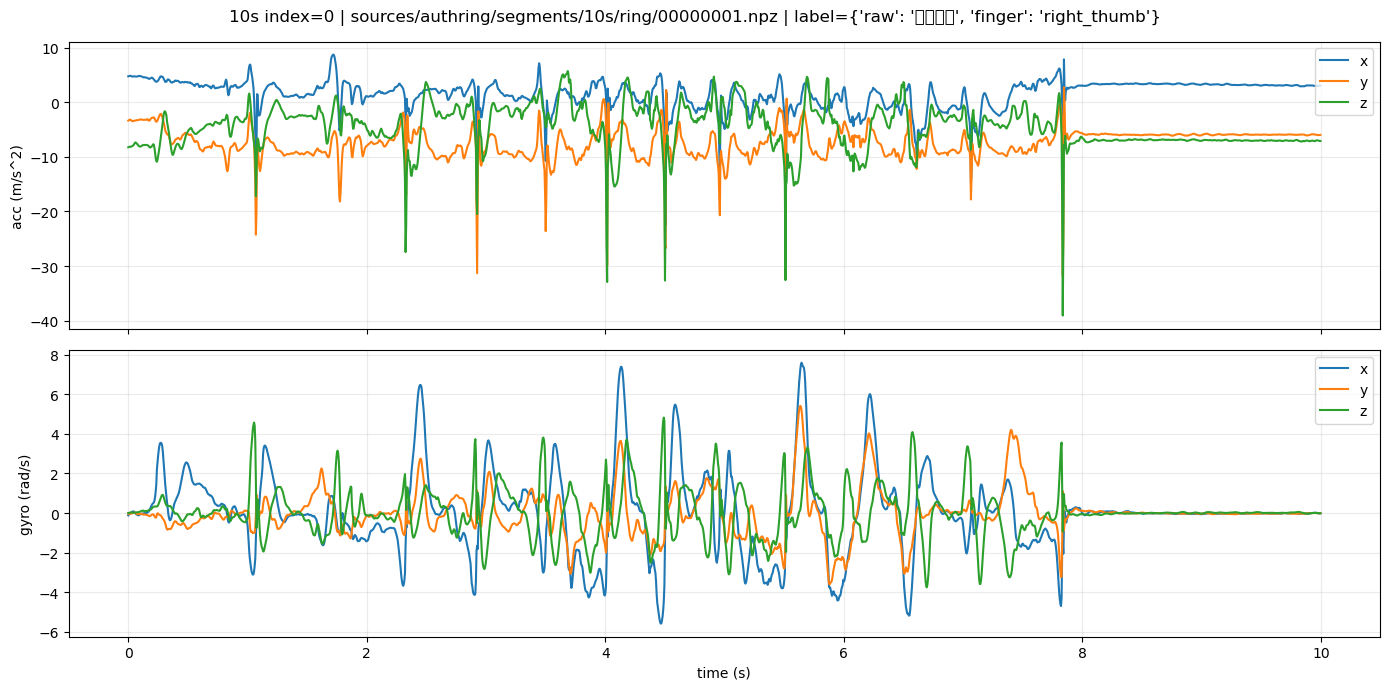

In [6]:
t = acc[:, 0] / 1000.0

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle(f'{MODE} index={INDEX} | {entry["dir"]} | label={entry["label"]}')

axes[0].plot(t, acc[:, 1], label='x')
axes[0].plot(t, acc[:, 2], label='y')
axes[0].plot(t, acc[:, 3], label='z')
axes[0].set_ylabel('acc (m/s^2)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.25)

axes[1].plot(t, gyro[:, 1], label='x')
axes[1].plot(t, gyro[:, 2], label='y')
axes[1].plot(t, gyro[:, 3], label='z')
axes[1].set_xlabel('time (s)')
axes[1].set_ylabel('gyro (rad/s)')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## 6. 看数值范围

这一步用来快速发现全 0、爆炸值、NaN/Inf 等明显问题。

In [7]:
def describe(name, arr):
    xyz = arr[:, 1:4]
    print(name)
    print('  min :', np.min(xyz, axis=0))
    print('  max :', np.max(xyz, axis=0))
    print('  mean:', np.mean(xyz, axis=0))
    print('  std :', np.std(xyz, axis=0))

describe('acc', acc)
describe('gyro', gyro)

acc
  min : [-22.441174 -31.658213 -39.046112]
  max : [8.7219305 2.735681  5.7078185]
  mean: [ 1.5447046 -7.395781  -4.6476016]
  std : [2.6546621 2.770776  4.0303507]
gyro
  min : [-5.586624  -3.602724  -3.7530396]
  max : [7.5971246 5.4170003 4.825917 ]
  mean: [ 0.0040832  -0.01879775  0.01229553]
  std : [2.0109184 1.1389041 1.1985816]


## 7. 随机抽查多个片段

这里只做轻量检查：shape、dtype、time range、label keys。

In [8]:
N = min(10, len(entries))
random.seed(0)
sample_indices = random.sample(range(len(entries)), N)

for idx in sample_indices:
    e = entries[idx]
    d = np.load(PROCESSED_ROOT / e['dir'])
    a = d['acc']
    g = d['gyro']
    print(idx, e['label'], a.shape, g.shape, a.dtype, g.dtype, float(a[0,0]), float(a[-1,0]))

108 {'raw': '右手拇指', 'finger': 'right_thumb'} (2000, 4) (2000, 4) float32 float32 0.0 9995.0
49 {'raw': '右手拇指', 'finger': 'right_thumb'} (2000, 4) (2000, 4) float32 float32 0.0 9995.0
97 {'raw': '右手拇指', 'finger': 'right_thumb'} (2000, 4) (2000, 4) float32 float32 0.0 9995.0
53 {'raw': '右手拇指', 'finger': 'right_thumb'} (2000, 4) (2000, 4) float32 float32 0.0 9995.0
5 {'raw': '右手拇指', 'finger': 'right_thumb'} (2000, 4) (2000, 4) float32 float32 0.0 9995.0
33 {'raw': '右手拇指', 'finger': 'right_thumb'} (2000, 4) (2000, 4) float32 float32 0.0 9995.0
65 {'raw': '右手拇指', 'finger': 'right_thumb'} (2000, 4) (2000, 4) float32 float32 0.0 9995.0
62 {'raw': '右手拇指', 'finger': 'right_thumb'} (2000, 4) (2000, 4) float32 float32 0.0 9995.0
51 {'raw': '右手拇指', 'finger': 'right_thumb'} (2000, 4) (2000, 4) float32 float32 0.0 9995.0
100 {'raw': '右手拇指', 'finger': 'right_thumb'} (2000, 4) (2000, 4) float32 float32 0.0 9995.0
